# Active Learning Introduction

The LECA workflow object nativeley supports basic Bayesian optimization and Active Learning routines, which are covered in the general introduction notebook.

For advanced Bayesian Optimization and Active Learning LECA provides an interface to the [PyALAF](https://pythonal.readthedocs.io/en/latest/) library. 
This allows for population-based active learning without the need to predefine a pool of possible interesting data points. Furthemore, batch-wise active learning is supported to allow for several suggestions simulatenously. This allows to take full advantage of high throughput experimentation setups. 
It is possible to chose either from pre-defined acquisition functions or define custom ones.

Data suggestion and acquisition can be easily automated by storing the suggested and acquired data for inspection first and easily adding it to the LECA workflow afterwards. 

## Import LECA and Standard Python Notebooks

In [ ]:
from LECA import prep, fit, analyze    # LECA Modules
from LECA import active_learning as al # LECA active learning module
import pandas as pd                    # Pandas DataFrames
import numpy as np                     # Numpy for standard math operations mostly
import matplotlib.pyplot as plt        # Matplotlib for plotting
random_state=0                         # (int) random_state for reproduceability, set to None if this is not desired

## Define Synthetic Experimental Setup

The setup is similar to the setup in the Synthetic LECA 1D introduction. 
However, we start with a lower number of initial data points and reduced noise

In [2]:
# True underlying function f(x) -> y
def f(x):
    """1D Polynomial function for our toy data."""
    return np.ravel(np.exp(-(x - 2)**2) + np.exp(-(x - 6)**2/10) + 1/ (x**2 + 1))


# Synthetic experimental setup with normal measurement error sigma
def run_experiment(x, sigma=0.1, n_resample=3): ## take dataframe -> output dataframe of experimental results
    result = pd.DataFrame(columns=['x','y'])
    for _ in range(n_resample):
        noisy_y = [y + np.random.normal(0, sigma) for y in f(x)]
        single_sample = pd.concat([x, pd.Series(noisy_y, name='y')],axis=1)
        result = pd.concat([result, single_sample],axis=0)
    return result.reset_index(drop=True)


Combined 30 datapoints down to 10


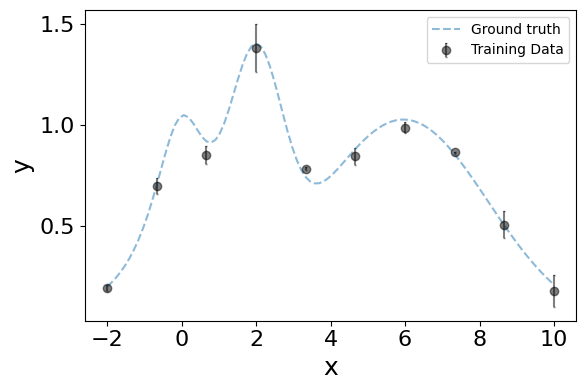

In [3]:
training_data_size = 10
sigma = 0.05 # Measurement noise
n_resample = 3 # How many times a given x is tested for objective function y (generating statistics)

# Generate training dataset
features, objective_functions = 'x', 'y'
starting_data = pd.DataFrame({features: np.linspace(-2,10,training_data_size)}) # sample points for initial model training
df = run_experiment(starting_data[features], sigma, n_resample)
# Use prep.combine_cut to combine repeated measurements
combined_df = prep.combine_cut(df, objective_functions, features)

%matplotlib inline
    
# Initialize plot figure
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)


n_samples = 100
X = np.linspace(-2, 10, n_samples)
ax.errorbar(X,f(X),label='Ground truth', fmt='--', alpha=0.5,capsize=1)
ax.errorbar(combined_df['x'],combined_df['y'],yerr=1.96*(combined_df['y_std_mean']),xerr=None,label='Training Data', fmt='o', c='black', alpha=0.5,capsize=1)

ax.set_ylabel('y', fontsize=18)
ax.set_xlabel('x', fontsize=18)
ax.tick_params(labelsize=16)
ax.legend()
plt.tight_layout()
plt.show()

## Start workflow and add a regression model

In [4]:
wf = fit.WorkFlow(combined_df,
                    [features],
                    objective_functions,
                    random_state=random_state,
                    polynomial_degree=3,
                    validation_holdout=0.0)

# Add a simple LR model
wf.add_regr('GPR', 'gpr_Matern_iso')

In [ ]:
n_samples = 50
X = np.linspace(-2, 10, n_samples)
x_input = pd.DataFrame({'x':X})
pred = wf.predict(x_input, X_scaled=False, min_max=True, return_std=True)

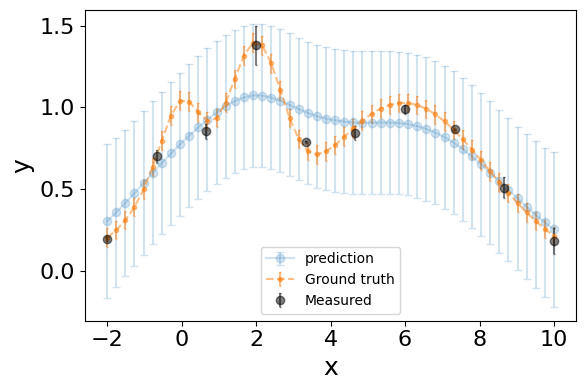

In [6]:
# Initialize plot figure
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)

ax.errorbar(X,pred['y'],yerr=1.96*(pred['y_std']),xerr=None,label='prediction', fmt='o-', alpha=0.2,capsize=3)
ax.errorbar(X,f(X),yerr=1.96*(sigma)/np.sqrt(3),xerr=None,label='Ground truth', fmt='.--', alpha=0.5,capsize=1)
ax.errorbar(wf.data['x'],wf.data['y'],yerr=1.96*(wf.data['y_std_mean']),xerr=None,label='Measured', fmt='o', c='black', alpha=0.5,capsize=1)


ax.set_ylabel('y', fontsize=18)
ax.set_xlabel('x', fontsize=18)
ax.tick_params(labelsize=16)
ax.legend()
plt.tight_layout()
plt.show()

## Use Active Learning to suggest new data

Demonstration of iterative semi-automatic active learning for LECA workflows.
After new data is suggested, it can be inspected, measurements can be done and then manually added to the ```ActiveLearner```.

### Perform Active Learning

In [7]:
active_learner = al.ActiveLearner(wf)
print(f'Number of Data points in active set: {len(active_learner.X)}')

Number of Data points in active set: 10


In [ ]:
# Perform the active learning experiment
# The ideal acquisition function is used as default
result = active_learner.single_step_al('GPR', 
                                       acquisition_function='ideal',
                                       lim = [[-2], [10]], 
                                       batch_size=3,
                                       random_state=random_state)

In [9]:
# Get the AL suggestions
suggested_X = active_learner.get_suggested_data()

# Evaluate suggested data
suggested_data = pd.DataFrame({features: suggested_X.flatten()}) # sample points for initial model training
df_suggested = run_experiment(suggested_data[features], sigma, n_resample)

# Use prep.combine_cut to combine repeated measurements
combined_df_suggested = prep.combine_cut(df_suggested, objective_functions, features)
combined_df_suggested

Combined 9 datapoints down to 3


,x,y,y_std,y_std_mean,count
0,-1.336176,0.373800,0.013212,0.007628,3
1,1.331334,1.155792,0.066373,0.038320,3
2,2.579341,1.184406,0.023278,0.013440,3


In [10]:
# Add the AL suggestions to the data set 
# Once the data is added, it is removed from the suggestions 
# In that case, no data can be added

active_learner.add_suggested_data(combined_df_suggested)
print(f'Number of Data points in active set: {len(active_learner.X)}')

Number of Data points in active set: 13


### Update Workflow

In [11]:
#Update the workflow and retrain it afterwards
active_learner.update_wf()
wf.retrain()

New indices: RangeIndex(start=10, stop=13, step=1)
Data successfully added to the LECA workflow


In [ ]:
n_samples = 50
X = np.linspace(-2, 10, n_samples)
x_input = pd.DataFrame({'x':X})
pred = wf.predict(x_input, X_scaled=False, min_max=True, return_std=True)

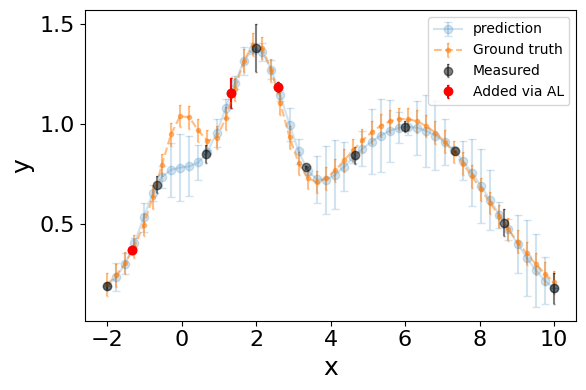

In [13]:
# Initialize plot figure
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)

ax.errorbar(X,pred['y'],yerr=1.96*(pred['y_std']),xerr=None,label='prediction', fmt='o-', alpha=0.2,capsize=3)
ax.errorbar(X,f(X),yerr=1.96*(sigma)/np.sqrt(3),xerr=None,label='Ground truth', fmt='.--', alpha=0.5,capsize=1)
ax.errorbar(wf.data['x'],wf.data['y'],yerr=1.96*(wf.data['y_std_mean']),xerr=None,label='Measured', fmt='o', c='black', alpha=0.5,capsize=1)
ax.errorbar(combined_df_suggested['x'],combined_df_suggested['y'],yerr=1.96*(combined_df_suggested['y_std_mean']),xerr=None,
            label='Added via AL', fmt='o', c='red', alpha=1,capsize=1)


ax.set_ylabel('y', fontsize=18)
ax.set_xlabel('x', fontsize=18)
ax.tick_params(labelsize=16)
ax.legend()
plt.tight_layout()
plt.show()

## Example for automated active learning and experimentation

Active Learning and data acquisition can be automated via data evaluation models. We define such a model and then use the automatic_al tool of LECA.

### Definition of data evaluation model

In [14]:
# Example class to evaluate the suggested data points
# The data evaluation model could be coupled to some experiments
# Whenever data is suggested by the AL routine, experiments can be performed and feed back into the active learner

class TestFunctionEvaluator():
    def __init__(self):
        self.n_features = 1
        
    def evaluate(self, x, **kwargs):
        x = np.array(x)
        if len(x.shape)==1:
            x = x.reshape(1,-1)
        
        noisy_y = [y + np.random.normal(0, sigma) for y in f(x)]
        return noisy_y

### Automatic Active Learning

In [ ]:
#Perform automatic active learning for two iterations
result = active_learner.automatic_al('GPR', 
                            acquisition_function='ideal',
                            lim = [[-2], [10]], 
                            batch_size=3,
                            active_learning_steps=2,
                            random_state=random_state,
                            data_evaluation_models=[TestFunctionEvaluator()]
                            )

In [16]:
#Inspect automatically collected data
collected_data = active_learner.get_collected_data()
collected_data

,x,y
0,-0.014587,1.076292
1,8.006089,0.703244
2,9.346408,0.335327
3,6.667496,1.018420
4,3.978556,0.751315
5,-1.005299,0.520838


### Update workflow

In [17]:
#Update the workflow and retrain it afterwards
active_learner.update_wf()
wf.retrain()

New indices: RangeIndex(start=13, stop=19, step=1)
Data successfully added to the LECA workflow


In [ ]:
n_samples = 50
X = np.linspace(-2, 10, n_samples)
x_input = pd.DataFrame({'x':X})
pred = wf.predict(x_input, X_scaled=False, min_max=True, return_std=True)

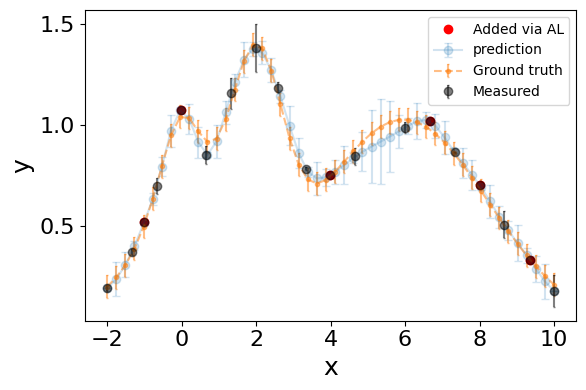

In [19]:
   # Initialize plot figure
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)

ax.errorbar(X,pred['y'],yerr=1.96*(pred['y_std']),xerr=None,label='prediction', fmt='o-', alpha=0.2,capsize=3)
ax.errorbar(X,f(X),yerr=1.96*(sigma)/np.sqrt(3),xerr=None,label='Ground truth', fmt='.--', alpha=0.5,capsize=1)
ax.errorbar(wf.data['x'],wf.data['y'],yerr=1.96*(wf.data['y_std_mean']),xerr=None,label='Measured', fmt='o', c='black', alpha=0.5,capsize=1)
ax.plot(collected_data['x'],collected_data['y'], 'ro', label='Added via AL')


ax.set_ylabel('y', fontsize=18)
ax.set_xlabel('x', fontsize=18)
ax.tick_params(labelsize=16)
ax.legend()
plt.tight_layout()
plt.show()